# Instalação

In [ ]:
# Install required packages.
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.0.1+cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 36.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 24.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!cat /proc/cpuinfo
!df -h
!cat /proc/meminfo
!nvidia-smi
!nvidia-smi --query-gpu=memory.total

processor	: 0
vendor_id	: AuthenticAMD
cpu family	: 23
model		: 49
model name	: AMD EPYC 7B12
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2249.998
cache size	: 512 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constant_tsc rep_good nopl nonstop_tsc cpuid extd_apicid tsc_known_freq pni pclmulqdq ssse3 fma cx16 sse4_1 sse4_2 movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm cmp_legacy cr8_legacy abm sse4a misalignsse 3dnowprefetch osvw topoext ssbd ibrs ibpb stibp vmmcall fsgsbase tsc_adjust bmi1 avx2 smep bmi2 rdseed adx smap clflushopt clwb sha_ni xsaveopt xsavec xgetbv1 clzero xsaveerptr arat npt nrip_save umip rdpid
bugs		: sysret_ss_attrs null_seg spectre_v1 spectre_v2 spec_store_bypass retbleed smt_rsb
bogomips	: 4499.

In [ ]:
!pip install nvidia-ml-py3
!pip install ipython-autotime
%load_ext autotime

  Preparing metadata (setup.py) ... done
  Created wheel for nvidia-ml-py3: filename=nvidia_ml_py3-7.352.0-py3-none-any.whl size=19171 sha256=c373283c8363da801e063e631395eea704e3943ce2f027d4bd642e22d6cbac4e
  Stored in directory: /root/.cache/pip/wheels/5c/d8/c0/46899f8be7a75a2ffd197a23c8797700ea858b9b34819fbf9e
Successfully built nvidia-ml-py3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.7 MB/s eta 0:00:00
time: 267 µs (started: 2023-08-29 00:52:06 +00:00)


# Utils

In [ ]:
import psutil
import os
from torch_geometric.profile import get_cpu_memory_from_gc, get_stats_summary

pid = os.getpid()
process = psutil.Process(pid)

def print_memory_and_cpu():
  # Get the CPU usage as a percentage
  cpu_percent = psutil.cpu_percent()

  cpu_percent_per_core = psutil.cpu_percent(percpu=True)

  # Get the memory usage in bytes
  memory_bytes = process.memory_info().rss

  # Convert the memory usage to MB or GB (optional)
  memory_mb = memory_bytes / 1024 / 1024
  memory_gb = memory_bytes / 1024 / 1024 / 1024

  cpu_gc = get_cpu_memory_from_gc() / 1024 / 1024 / 1024
  # stats_summary = get_stats_summary(stats_list=)

  # Return the results
  return cpu_percent, memory_gb, cpu_gc, cpu_percent_per_core


time: 1.48 s (started: 2023-08-29 00:52:06 +00:00)


In [ ]:
import psutil

def print_psi():
  # Get the overall PSI va

  # Print the PSI values
  print("Overall PSI values: ", psi)

  # Iterate over all running processes and print their PSI values
  for proc in psutil.process_iter(['pid', 'name']):
      io_counters = proc.io_counters()
      if io_counters:
          print(f"Process {proc.pid} ({proc.info['name']}): {io_counters.psi}")

time: 642 µs (started: 2023-08-29 00:52:08 +00:00)


In [ ]:
import pynvml

def monitor_gpu():
    try:
        pynvml.nvmlInit()

        # Get the handle of the first GPU
        handle = pynvml.nvmlDeviceGetHandleByIndex(0)

        # Get the GPU name
        name = pynvml.nvmlDeviceGetName(handle)

        # Get the current GPU utilization
        utilization = pynvml.nvmlDeviceGetUtilizationRates(handle)
        gpu_utilization = utilization.gpu

        # Get the current GPU memory usage
        meminfo = pynvml.nvmlDeviceGetMemoryInfo(handle)
        gpu_used_memory = meminfo.used

        gpu_used_memory =  gpu_used_memory / (1024 * 1024 * 1024)

        pynvml.nvmlShutdown()
        return gpu_utilization, gpu_used_memory
    except:
      return 0,0

time: 5.53 ms (started: 2023-08-29 00:52:08 +00:00)


In [ ]:
# Helper function for visualization.
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

time: 1.05 s (started: 2023-08-29 00:52:08 +00:00)


# Load Dataset

In [ ]:
from torch_geometric.datasets import Coauthor
from torch_geometric.transforms import RandomNodeSplit

use_cuda_if_available = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = RandomNodeSplit()

dataset = Coauthor(name="CS", root="/tmp/Coauthor", transform=transform)

Processing...
Done!


time: 3.6 s (started: 2023-08-29 00:52:09 +00:00)


# Imports

In [ ]:
import torch
from tabulate import tabulate

time: 6.99 ms (started: 2023-08-29 00:52:12 +00:00)


In [ ]:
header = []
header.append(['Dataset', 'N. Graphs', 'N. Features', 'N. Classes', 'N. Nodes', 'N. Edges', 'Avg. Node Degree', 'N. Training Nodes', 'Training node label rate', 'Has isolated nodes', 'Has self-loops', 'Undirected'])
print()

data = dataset[0]  # Get the first graph object.
data = data.to(device)

print()
print(f'data: {data}')
print(f'train mask: {data.train_mask}')

header.append([dataset, len(dataset), dataset.num_features, dataset.num_classes, data.num_nodes, data.num_edges,
               f'{data.num_edges / data.num_nodes:.2f}', data.train_mask.sum(), f'{int(data.train_mask.sum()) / data.num_nodes:.3f}',
               data.has_isolated_nodes(), data.has_self_loops(), data.is_undirected()])

print(tabulate(header, tablefmt="simple"))
# print(tabulate(header, tablefmt="latex"))



data: Data(x=[18333, 6805], edge_index=[2, 163788], y=[18333], train_mask=[18333], val_mask=[18333], test_mask=[18333])
train mask: tensor([ True,  True,  True,  ...,  True, False, False])
------------  ---------  -----------  ----------  --------  --------  ----------------  -----------------  ------------------------  ------------------  --------------  ----------
Dataset       N. Graphs  N. Features  N. Classes  N. Nodes  N. Edges  Avg. Node Degree  N. Training Nodes  Training node label rate  Has isolated nodes  Has self-loops  Undirected
CoauthorCS()  1          6805         15          18333     163788    8.93              16833              0.918                     False               False           True
------------  ---------  -----------  ----------  --------  --------  ----------------  -----------------  ------------------------  ------------------  --------------  ----------
time: 68.7 ms (started: 2023-08-29 00:52:12 +00:00)


# Clustering Data

In [ ]:
from torch_geometric.loader import ClusterData, ClusterLoader

torch.manual_seed(12345)
cluster_data = ClusterData(data, num_parts=128)  # 1. Create subgraphs.
train_loader = ClusterLoader(cluster_data, batch_size=32, shuffle=True) # 2. Stochastic partioning scheme.

Computing METIS partitioning...
Done!


time: 568 ms (started: 2023-08-29 00:52:12 +00:00)


# GCN

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=16)
model = model.to(device)
print(model)

GCN(
  (conv1): GCNConv(6805, 16)
  (conv2): GCNConv(16, 15)
)
time: 15 ms (started: 2023-08-29 00:52:13 +00:00)


# Evaluate and Visualize

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
gpu_percent, gpu_memory = monitor_gpu()
print ('Before execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core)
print(gpu_percent, gpu_memory)
print(torch.cuda.is_available())

Before execution: 

70.1 1.4862861633300781 0.9379347087815404 [71.7, 68.4]
0 0
False
time: 208 ms (started: 2023-08-29 00:52:13 +00:00)


In [ ]:
from IPython.display import Javascript
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()
      # for sub_data in train_loader:  # Iterate over each mini-batch.
      out = model(data.x, data.edge_index)  # Perform a single forward pass.
      loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
      loss.backward()  # Derive gradients.
      optimizer.step()  # Update parameters based on gradients.
      optimizer.zero_grad()  # Clear gradients.

def test():
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.

      accs = []
      for mask in [data.train_mask, data.val_mask, data.test_mask]:
          correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
          accs.append(int(correct.sum()) / int(mask.sum()))  # Derive ratio of correct predictions.
      return accs
# print(f'Epoch\tTrain Acc\tVal Acc\tTest Acc\tCPU Percent\tMemory Use\tGarbage Collector')
results = []
results_formatted = []
results_formatted.append(['Epoch\t', 'TrainAcc.\t', 'ValAcc.\t', 'CPUPercent.\t', 'MemoryUse\t', 'GpuPercent.\t', 'GpuMem.\t\n'])

for epoch in range(1, 101):
    loss = train()
    train_acc, val_acc, test_acc = test()
    cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
    gpu_percent, gpu_memory = monitor_gpu()
    results.append([epoch, train_acc, test_acc, cpu_percent,memory_mb, cpu_gc, gpu_percent, gpu_memory])
    results_formatted.append([f'{epoch:03d}\t', f'{train_acc:.3f}\t', f'{test_acc:.3f}\t', f'{cpu_percent:.3f}\t', f'{memory_mb:.3f}\t', f'{gpu_percent:.3f}\t', f'{gpu_memory:.3f}\t\n'])
    print(f'{epoch:03d}')
print (results)

<IPython.core.display.Javascript object>

001
002
003
004
005
006
007
008
009
010
011
012
013
014
015
016
017
018
019
020
021
022
023
024
025
026
027
028
029
030
031
032
033
034
035
036
037
038
039
040
041
042
043
044
045
046
047
048
049
050
051
052
053
054
055
056
057
058
059
060
061
062
063
064
065
066
067
068
069
070
071
072
073
074
075
076
077
078
079
080
081
082
083
084
085
086
087
088
089
090
091
092
093
094
095
096
097
098
099
100
[[1, 0.2764213152735698, 0.294, 96.4, 1.5183563232421875, 0.9387479620054364, 0, 0], [2, 0.41501811917067666, 0.438, 100.0, 1.5230789184570312, 0.9387479620054364, 0, 0], [3, 0.5902097071229133, 0.604, 100.0, 1.5231475830078125, 0.9387479620054364, 0, 0], [4, 0.6983306600130695, 0.688, 100.0, 1.5030136108398438, 0.9387479620054364, 0, 0], [5, 0.7560149705934771, 0.753, 100.0, 1.5032691955566406, 0.9387479620054364, 0, 0], [6, 0.784292758272441, 0.783, 100.0, 1.5032691955566406, 0.9387479620054364, 0, 0], [7, 0.800273272738074, 0.807, 100.0, 1.5342330932617188, 0.9387479620054364, 0, 0], [8, 0.

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
gpu_percent, gpu_memory = monitor_gpu()
print ('After execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core, gpu_percent, gpu_memory)

After execution: 

58.8 1.5343666076660156 0.9387479620054364 [50.0, 62.5] 0 0
time: 69.4 ms (started: 2023-08-29 00:53:09 +00:00)


In [ ]:
def split_lattex(data_structure):
  # Split the data structure into header and rows
  header = data_structure[0]
  rows = data_structure[1:]

  set1_rows = rows[:40]
  set2_rows = rows[40:80]
  set3_rows = rows[80:]

  # Create three matrices with headers and rows
  matrix1 = [header] + set1_rows
  matrix2 = [header] + set2_rows
  matrix3 = [header] + set3_rows
  return matrix1, matrix2, matrix3

time: 495 µs (started: 2023-08-29 00:53:09 +00:00)


In [ ]:
from tabulate import tabulate

# print (results_formatted)
latex1, latex2, latex3 = split_lattex(results_formatted)


time: 492 µs (started: 2023-08-29 00:53:09 +00:00)


In [ ]:
print(tabulate(latex1, tablefmt="latex"))

\begin{tabular}{lllllll}
\hline
 Epoch & TrainAcc. & ValAcc. & CPUPercent. & MemoryUse & GpuPercent. & GpuMem. \\
 001   & 0.276     & 0.294   & 96.400      & 1.518     & 0.000       & 0.000   \\
 002   & 0.415     & 0.438   & 100.000     & 1.523     & 0.000       & 0.000   \\
 003   & 0.590     & 0.604   & 100.000     & 1.523     & 0.000       & 0.000   \\
 004   & 0.698     & 0.688   & 100.000     & 1.503     & 0.000       & 0.000   \\
 005   & 0.756     & 0.753   & 100.000     & 1.503     & 0.000       & 0.000   \\
 006   & 0.784     & 0.783   & 100.000     & 1.503     & 0.000       & 0.000   \\
 007   & 0.800     & 0.807   & 100.000     & 1.534     & 0.000       & 0.000   \\
 008   & 0.825     & 0.827   & 100.000     & 1.523     & 0.000       & 0.000   \\
 009   & 0.849     & 0.850   & 100.000     & 1.524     & 0.000       & 0.000   \\
 010   & 0.865     & 0.868   & 100.000     & 1.503     & 0.000       & 0.000   \\
 011   & 0.872     & 0.876   & 100.000     & 1.503     & 0.000    

In [ ]:
print(tabulate(latex2, tablefmt="latex"))

\begin{tabular}{lllllll}
\hline
 Epoch & TrainAcc. & ValAcc. & CPUPercent. & MemoryUse & GpuPercent. & GpuMem. \\
 041   & 0.935     & 0.931   & 53.300      & 1.523     & 0.000       & 0.000   \\
 042   & 0.936     & 0.932   & 52.200      & 1.503     & 0.000       & 0.000   \\
 043   & 0.937     & 0.932   & 53.200      & 1.523     & 0.000       & 0.000   \\
 044   & 0.937     & 0.931   & 53.800      & 1.503     & 0.000       & 0.000   \\
 045   & 0.938     & 0.931   & 51.100      & 1.524     & 0.000       & 0.000   \\
 046   & 0.938     & 0.931   & 54.500      & 1.503     & 0.000       & 0.000   \\
 047   & 0.939     & 0.932   & 52.200      & 1.503     & 0.000       & 0.000   \\
 048   & 0.939     & 0.931   & 52.600      & 1.524     & 0.000       & 0.000   \\
 049   & 0.939     & 0.931   & 53.100      & 1.523     & 0.000       & 0.000   \\
 050   & 0.939     & 0.930   & 53.000      & 1.523     & 0.000       & 0.000   \\
 051   & 0.939     & 0.929   & 52.600      & 1.523     & 0.000    

In [ ]:
print(tabulate(latex3, tablefmt="latex"))

\begin{tabular}{lllllll}
\hline
 Epoch & TrainAcc. & ValAcc. & CPUPercent. & MemoryUse & GpuPercent. & GpuMem. \\
 081   & 0.946     & 0.932   & 51.600      & 1.524     & 0.000       & 0.000   \\
 082   & 0.946     & 0.933   & 55.300      & 1.524     & 0.000       & 0.000   \\
 083   & 0.947     & 0.933   & 51.600      & 1.523     & 0.000       & 0.000   \\
 084   & 0.947     & 0.932   & 56.300      & 1.503     & 0.000       & 0.000   \\
 085   & 0.947     & 0.932   & 51.100      & 1.534     & 0.000       & 0.000   \\
 086   & 0.947     & 0.933   & 52.700      & 1.523     & 0.000       & 0.000   \\
 087   & 0.947     & 0.933   & 53.300      & 1.534     & 0.000       & 0.000   \\
 088   & 0.947     & 0.932   & 51.600      & 1.523     & 0.000       & 0.000   \\
 089   & 0.948     & 0.932   & 54.700      & 1.524     & 0.000       & 0.000   \\
 090   & 0.948     & 0.933   & 51.600      & 1.523     & 0.000       & 0.000   \\
 091   & 0.948     & 0.934   & 54.800      & 1.523     & 0.000    

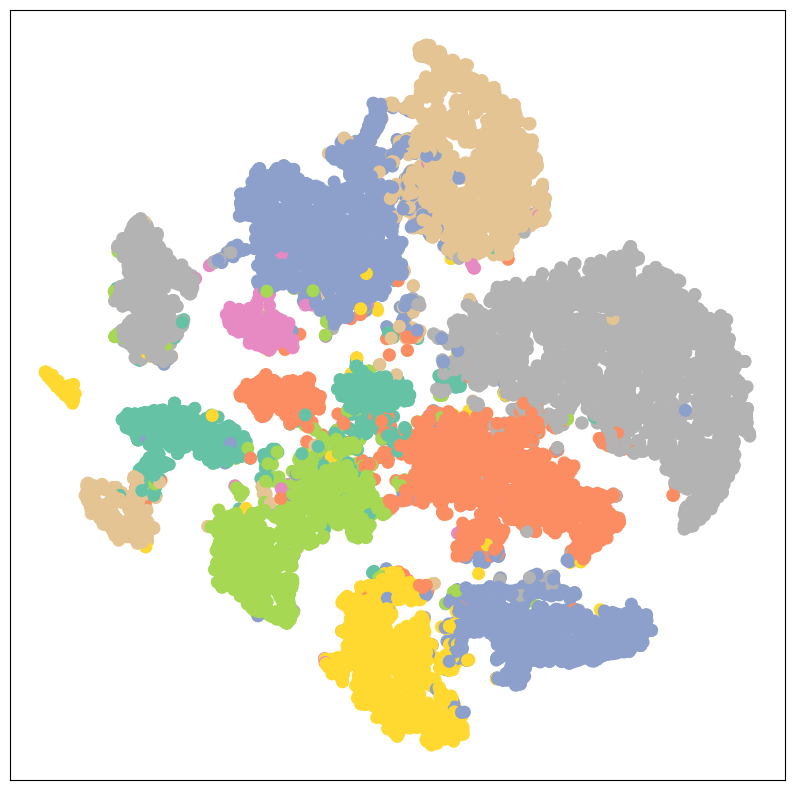

time: 2min 34s (started: 2023-08-29 00:53:09 +00:00)


In [ ]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

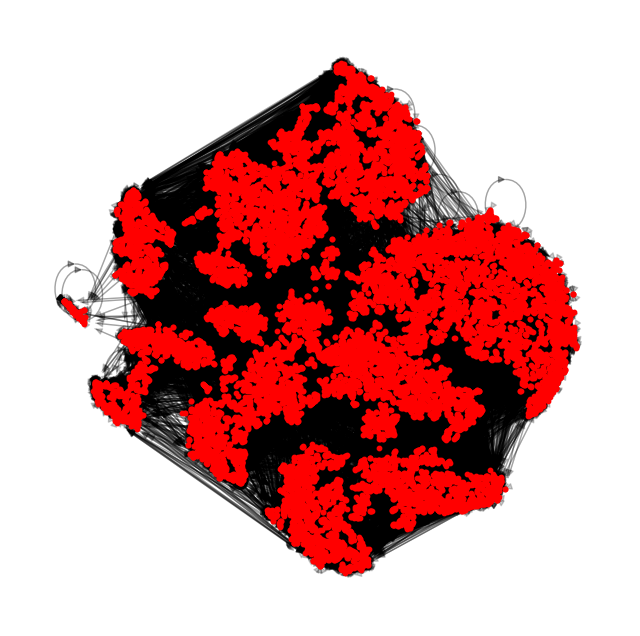

time: 11min 54s (started: 2023-08-29 00:55:44 +00:00)


In [ ]:
import networkx as nx
from torch_geometric.utils import to_networkx

# Obtenha as embeddings dos nós do grafo
with torch.no_grad():
    embeddings = model(dataset[0].x, dataset[0].edge_index)
    embeddings = embeddings.numpy()

# Reduza a dimensionalidade das embeddings usando o t-SNE
tsne = TSNE(n_components=2)
embeddings = tsne.fit_transform(embeddings)

# Obtenha o grafo em formato NetworkX
G = to_networkx(dataset[0])

# Plote os nós e arestas usando o Matplotlib
plt.figure(figsize=(8,8))
pos = {i: embeddings[i] for i in range(len(G.nodes))}
nx.draw_networkx_nodes(G, pos=pos, node_size=10, node_color='r')
nx.draw_networkx_edges(G, pos=pos, alpha=0.2)
plt.axis('off')
plt.show()

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
print ('After execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core)

After execution: 

62.1 3.447540283203125 0.9937845105305314 [60.9, 63.3]
time: 2.85 s (started: 2023-08-29 01:07:38 +00:00)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

epochs = [row[0] for row in results]
cpu_values = [row[3] for row in results]
mem_values = [row[4] for row in results]

gpu_values = [row[6] for row in results]
gpu_mem_values = [row[7] for row in results]


time: 422 ms (started: 2023-08-29 01:07:41 +00:00)


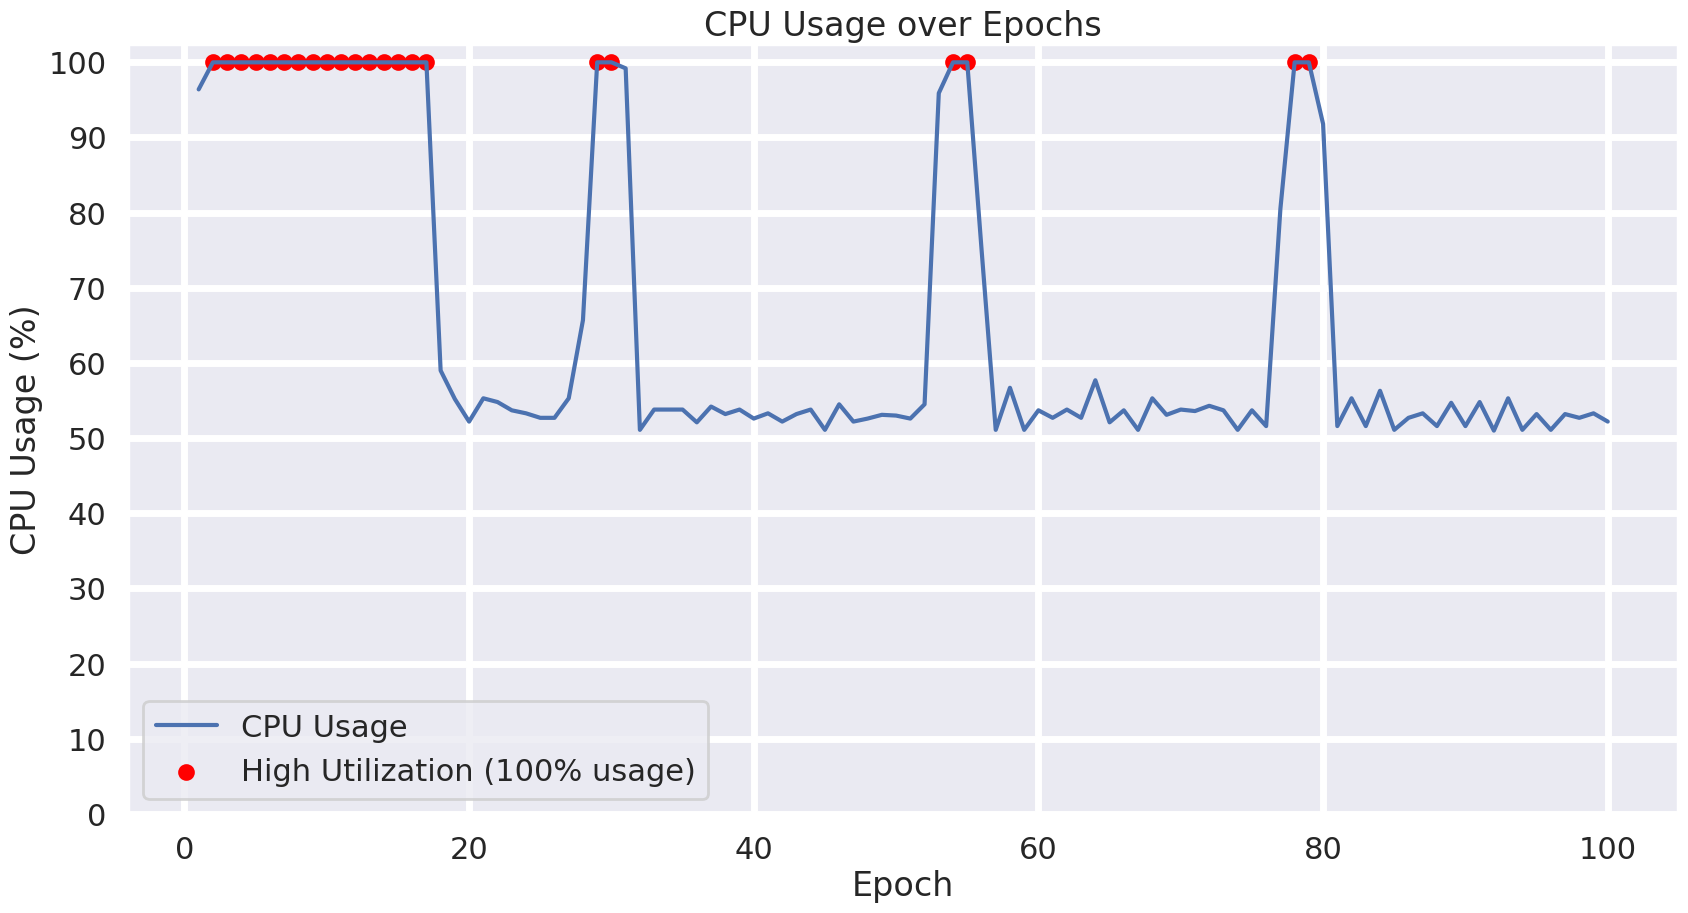

Percentage of High Utilization:  22.0
time: 321 ms (started: 2023-08-29 01:07:41 +00:00)


In [ ]:
# PLOT CPU USAGE

peak_indices, _ = find_peaks(cpu_values, height=100, plateau_size=1)

indices = [i for i in range(len(cpu_values)) if cpu_values[i] == 100.0]

plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, cpu_values, label='CPU Usage')
plt.scatter([epochs[i] for i in indices], [100]*len(indices), color='red', s=100, label='High Utilization (100% usage)')
# plt.scatter([epochs[i] for i in peak_indices], [100]*len(peak_indices), color='blue', s=100, label='Peak of Saturation')
plt.title('CPU Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('CPU Usage (%)')
plt.yticks(range(0, 101, 10))
plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

saturation = (len(indices) / len(epochs)) * 100
print('Percentage of High Utilization: ', saturation)

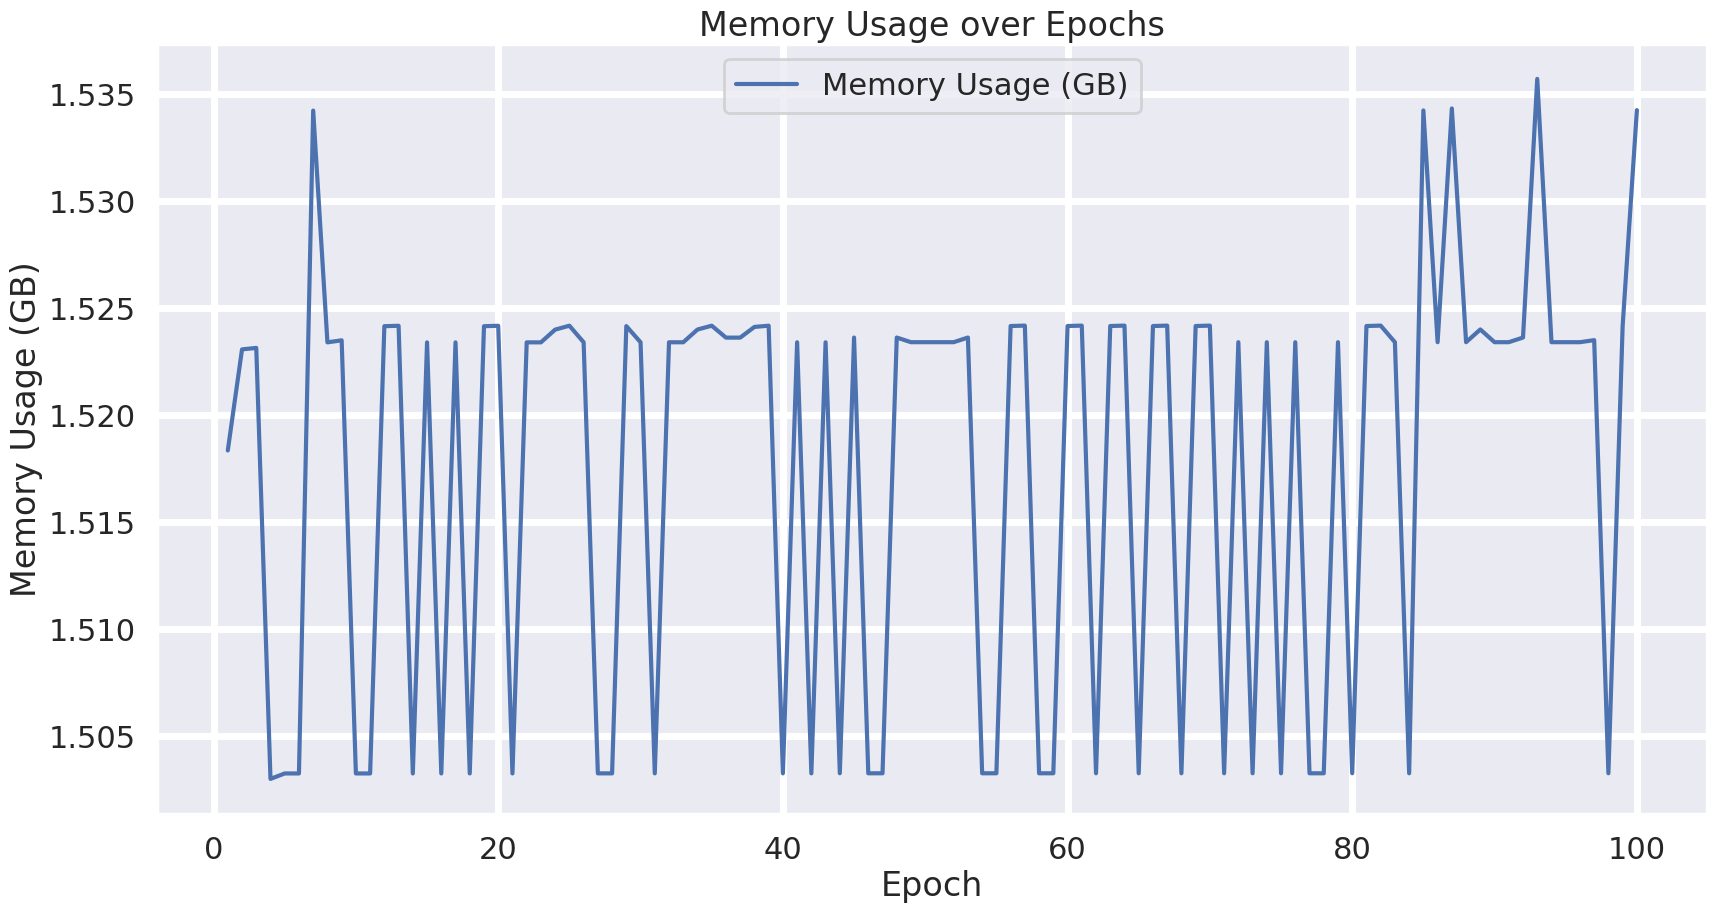

time: 337 ms (started: 2023-08-29 01:07:41 +00:00)


In [ ]:
# PLOT MEMORY USAGE
plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, mem_values, label='Memory Usage (GB)')
plt.title('Memory Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Memory Usage (GB)')
# plt.yticks(range(0, 101, 10))
# plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

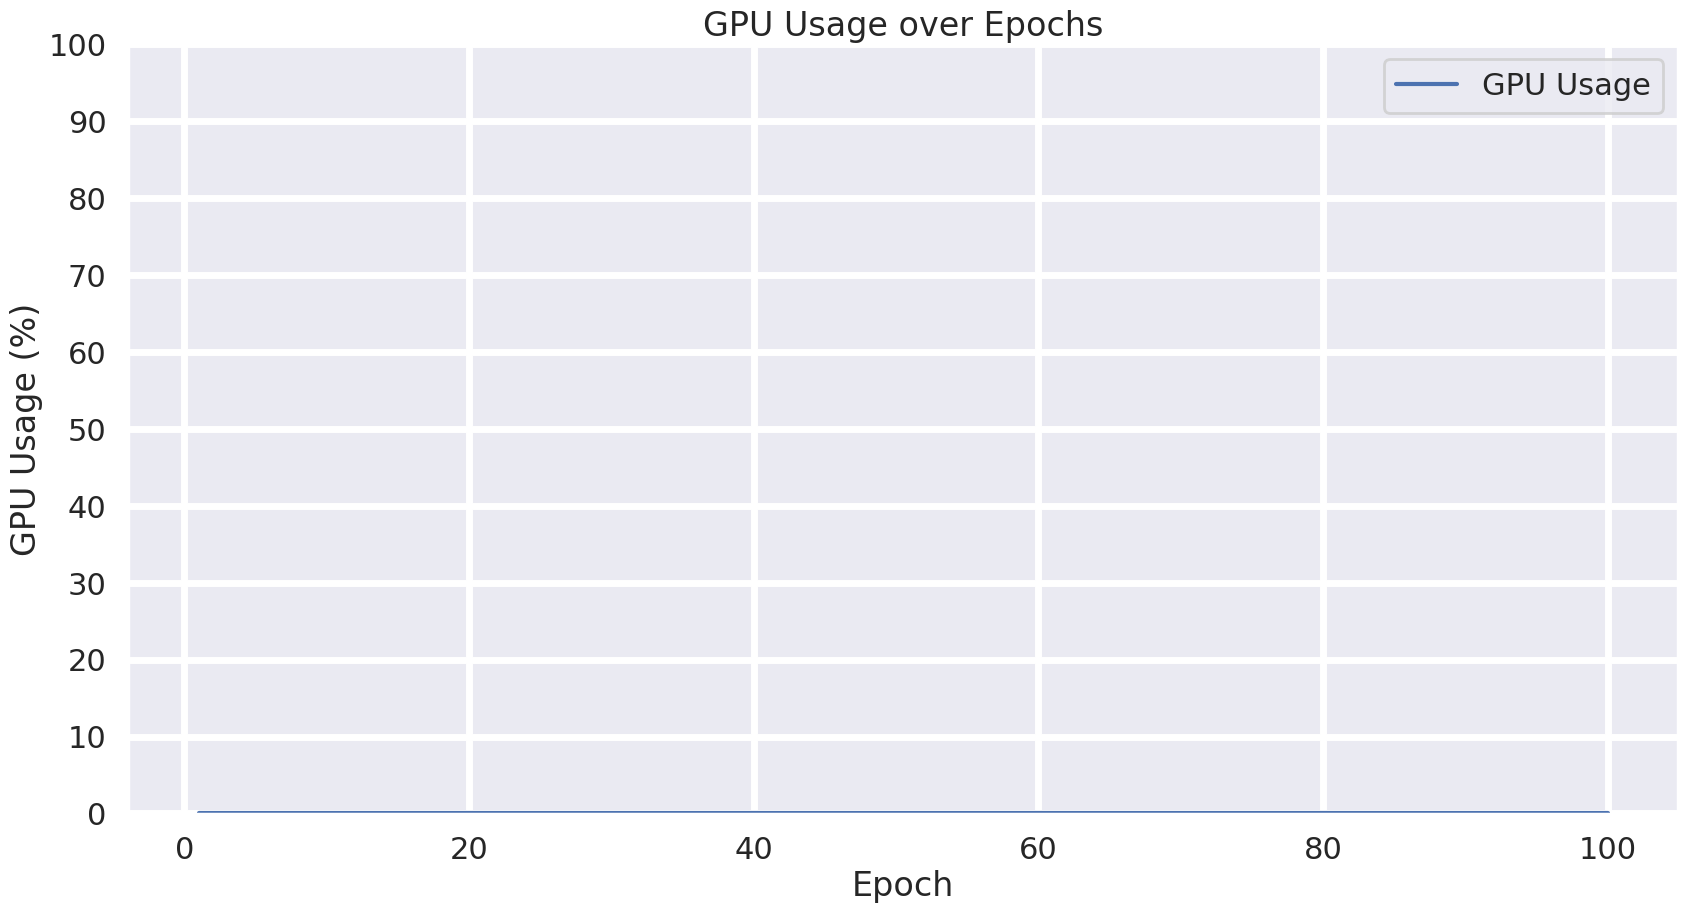

time: 291 ms (started: 2023-08-29 01:07:42 +00:00)


In [ ]:
# PLOT GPU USAGE
plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, gpu_values, label='GPU Usage')
plt.title('GPU Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('GPU Usage (%)')
plt.yticks(range(0, 101, 10))
plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

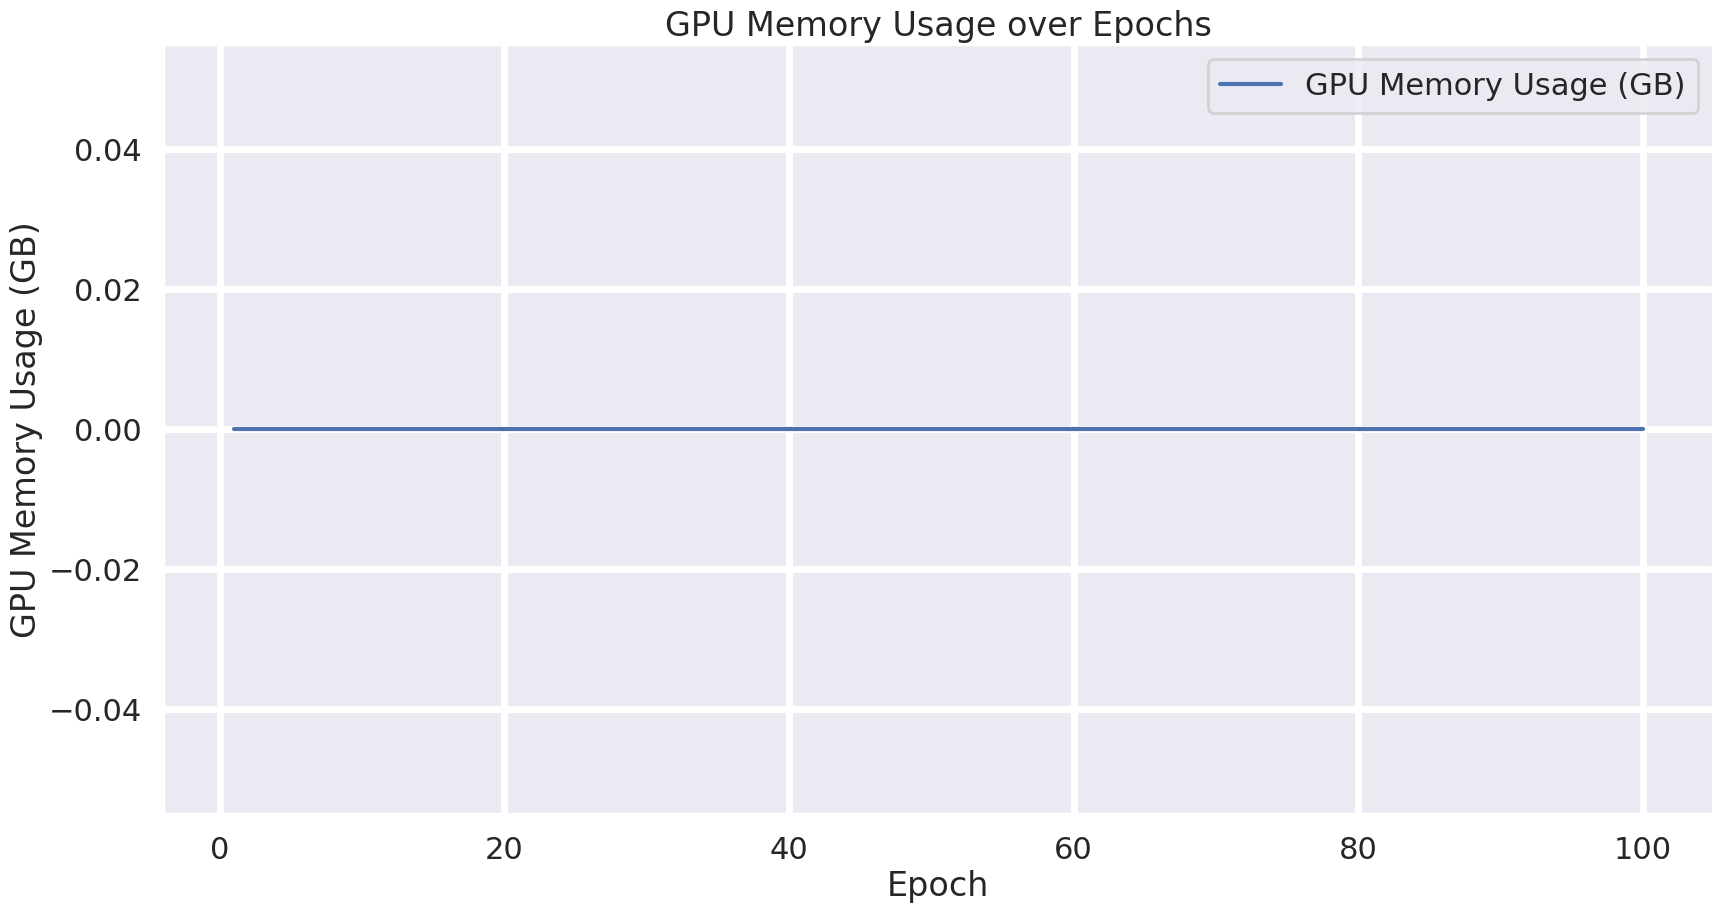

time: 282 ms (started: 2023-08-29 01:07:42 +00:00)


In [ ]:
# PLOT GPU MEMORY USAGE
plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, gpu_mem_values, label='GPU Memory Usage (GB)')
plt.title('GPU Memory Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('GPU Memory Usage (GB)')
# plt.yticks(range(0, 101, 10))
# plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

In [ ]:
psutil.cpu_stats()

scpustats(ctx_switches=2610163, interrupts=2287704, soft_interrupts=978209, syscalls=0)

time: 2.03 ms (started: 2023-08-29 01:07:42 +00:00)


time: 9.72 ms (started: 2023-08-29 01:07:42 +00:00)
